# Real-Time Anomaly Detection in Big Data Streams Using LSTM Autoencoders
### A Distributed Processing Approach

**Student ID:** 2026257
**Module:** Advanced Data Analytics / Big Data Storage and Processing, Integrated CA1 Sem 2
**Dataset:** Credit Card Fraud Detection (Kaggle, mlg-ulb/creditcardfraud)



## 0. Environment Setup

In [26]:
# !pip install pyspark==3.5.1 tensorflow scikit-learn pandas matplotlib seaborn kagglehub --quiet
print("Skip re-running if packages are already installed.")


Skip re-running if packages are already installed.


In [27]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_curve, roc_auc_score, roc_curve, f1_score
)

print("PySpark:", pyspark.__version__, "| TensorFlow:", tf.__version__)


PySpark: 4.0.4 | TensorFlow: 2.21.0


## 1. Initialize Spark Session (Big Data Component)

In [28]:
spark = (
    SparkSession.builder
    .appName("CA1_BigData_NeuralNetworks")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark


## 2. Load Dataset

Download `creditcard.csv` from https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


In [29]:
import os, glob

# Auto-detect the dataset CSV in the current folder (handles any filename variation).
# If you renamed the file or placed it elsewhere, just set csv_path manually below instead.
candidates = glob.glob("*.csv") + glob.glob("/content/*.csv") + glob.glob("/content/sample_data/*.csv")
candidates = [c for c in candidates if "sample_data" not in c or "creditcard" in c.lower()]

if candidates:
    csv_path = candidates[0]
    print("Auto-detected dataset file:", csv_path)
else:
    csv_path = "/content/creditcard.csv"
    print("No CSV auto-detected -- make sure 'creditcard.csv' is uploaded, or set csv_path manually.")

df_spark = spark.read.csv(csv_path, header=True, inferSchema=True)
df_spark.printSchema()
print("Row count:", df_spark.count())
df_spark.show(5)


Auto-detected dataset file: creditcard.csv
root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable = true)
 |-- V25: double (nullable = true)
 |-- V26: double (nullable = true)
 |-- V27: doubl

## 3. Exploratory Data Analysis (Distributed + Local)


In [30]:
null_counts = df_spark.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_spark.columns])
null_counts.show()


+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|Time| V1| V2| V3| V4| V5| V6| V7| V8| V9|V10|V11|V12|V13|V14|V15|V16|V17|V18|V19|V20|V21|V22|V23|V24|V25|V26|V27|V28|Amount|Class|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|   0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|     0|    0|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+



   Class   count
0      1     492
1      0  284315
Fraud cases: 0.1727% of total — highly imbalanced, hence an UNSUPERVISED approach.


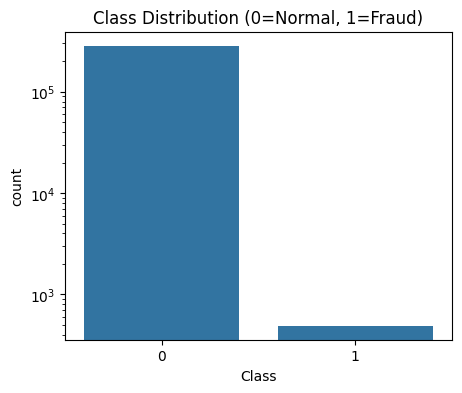

In [31]:
label_col = "Class"  # 0 = normal, 1 = fraud

class_counts = df_spark.groupBy(label_col).count().toPandas()
print(class_counts)

fraud_pct = class_counts.loc[class_counts[label_col] == 1, "count"].values[0] / class_counts["count"].sum() * 100
print(f"Fraud cases: {fraud_pct:.4f}% of total — highly imbalanced, hence an UNSUPERVISED approach.")

plt.figure(figsize=(5,4))
sns.barplot(x=label_col, y="count", data=class_counts)
plt.title("Class Distribution (0=Normal, 1=Fraud)")
plt.yscale("log")
plt.show()


In [32]:
amount_summary = df_spark.groupBy(label_col).agg(
    F.mean("Amount").alias("mean_amount"),
    F.stddev("Amount").alias("std_amount"),
    F.max("Amount").alias("max_amount")
).toPandas()
print(amount_summary)


   Class  mean_amount  std_amount  max_amount
0      1   122.211321  256.683288     2125.87
1      0    88.291022  250.105092    25691.16


## 4. Distributed Preprocessing → Model-Ready Data

Spark handles the ETL stage. We then hand off a cleaned, scaled array to the deep learning
framework — this reflects a realistic big-data-to-ML pipeline pattern.


In [33]:
df = df_spark.toPandas()  # handoff point: Spark -> Pandas/NumPy for DL training

feature_cols = [c for c in df.columns if c != label_col]
X = df[feature_cols].values
y = df[label_col].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_normal = X_scaled[y == 0]
X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)

print("Train (normal only):", X_train.shape, "| Val:", X_val.shape, "| Full (for testing):", X_scaled.shape)


Train (normal only): (227452, 30) | Val: (56863, 30) | Full (for testing): (284807, 30)


## 5. Shared Evaluation Function

In [34]:
def evaluate_autoencoder(model, X_all, y_all, label="Model", threshold=None, threshold_percentile=95):
    reconstructions = model.predict(X_all, verbose=0)
    mse = np.mean(np.power(X_all.reshape(X_all.shape[0], -1) - reconstructions.reshape(reconstructions.shape[0], -1), 2), axis=1)

    if threshold is None:
        threshold = np.percentile(mse, threshold_percentile)

    y_pred = (mse > threshold).astype(int)

    print(f"--- {label} ---")
    print("Threshold used:", threshold)
    print(classification_report(y_all, y_pred, digits=4))
    auc = roc_auc_score(y_all, mse)
    f1 = f1_score(y_all, y_pred)
    print(f"ROC-AUC: {auc:.4f} | F1: {f1:.4f}")

    return {"mse": mse, "y_pred": y_pred, "auc": auc, "f1": f1, "threshold": threshold}

results = {}


## 6. Iteration 1 — Baseline Dense Autoencoder

Simplest reasonable architecture. This is our baseline to beat.


In [35]:
def build_dense_autoencoder(input_dim, encoding_dim=14):
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(64, activation="relu")(inputs)
    x = layers.Dense(encoding_dim, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(input_dim, activation="linear")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse")
    return model

input_dim = X_train.shape[1]
ae_v1 = build_dense_autoencoder(input_dim, encoding_dim=14)
ae_v1.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 14)             │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,804 (22.67 KB)

 Trainable params: 5,804 (22.67 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history_v1 = ae_v1.fit(
    X_train, X_train,
    epochs=20, batch_size=256,
    validation_data=(X_val, X_val),
    shuffle=True, verbose=1
)


Epoch 1/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.4257 - val_loss: 0.2232
Epoch 2/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1746 - val_loss: 0.1400
Epoch 3/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1260 - val_loss: 0.1122
Epoch 4/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1056 - val_loss: 0.0990
Epoch 5/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0943 - val_loss: 0.0913
Epoch 6/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0858 - val_loss: 0.0808
Epoch 7/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0782 - val_loss: 0.0748
Epoch 8/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0729 - val_loss: 0.0699
Epoch 9/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0683 - val_loss: 0.0667
Epoch 10/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0645 - val_loss: 0.0620
Epoch 11/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0612 - val_loss: 0.0602
Epoch 12/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

In [37]:
results["v1_dense"] = evaluate_autoencoder(ae_v1, X_scaled, y, label="Iteration 1: Dense Autoencoder (95th pct threshold)")


--- Iteration 1: Dense Autoencoder (95th pct threshold) ---
Threshold used: 0.18920387100632155
              precision    recall  f1-score   support

           0     0.9997    0.9514    0.9750    284315
           1     0.0296    0.8557    0.0572       492

    accuracy                         0.9512    284807
   macro avg     0.5147    0.9035    0.5161    284807
weighted avg     0.9981    0.9512    0.9734    284807

ROC-AUC: 0.9446 | F1: 0.0572


## 7. Iteration 2 — LSTM Autoencoder (Sequence-Aware)

**Why this change:** transactions arrive as a stream over time. An LSTM autoencoder gives the
model short-term temporal context instead of treating every transaction independently — more
representative of a real streaming big-data scenario.


In [38]:
def create_sequences(data, window_size=5):
    return np.array([data[i:i+window_size] for i in range(len(data) - window_size + 1)])

WINDOW_SIZE = 5  # Default works well for this dataset. Optional: try 3 or 10 and compare for your report's iteration discussion.

X_train_seq = create_sequences(X_train, WINDOW_SIZE)
X_val_seq = create_sequences(X_val, WINDOW_SIZE)
X_all_seq = create_sequences(X_scaled, WINDOW_SIZE)
y_all_seq = y[WINDOW_SIZE-1:]

print("Train seq:", X_train_seq.shape, "| Full seq:", X_all_seq.shape)


Train seq: (227448, 5, 30) | Full seq: (284803, 5, 30)


In [39]:
def build_lstm_autoencoder(window_size, n_features, latent_dim=16):
    inputs = keras.Input(shape=(window_size, n_features))
    encoded = layers.LSTM(latent_dim, activation="relu")(inputs)
    repeated = layers.RepeatVector(window_size)(encoded)
    decoded = layers.LSTM(n_features, activation="relu", return_sequences=True)(repeated)
    model = keras.Model(inputs, decoded)
    model.compile(optimizer="adam", loss="mse")
    return model

ae_v2 = build_lstm_autoencoder(WINDOW_SIZE, X_train.shape[1], latent_dim=16)
ae_v2.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 5, 30)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 16)             │         3,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 5, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 5, 30)          │         5,640 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,648 (33.78 KB)

 Trainable params: 8,648 (33.78 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history_v2 = ae_v2.fit(
    X_train_seq, X_train_seq,
    epochs=20, batch_size=256,
    validation_data=(X_val_seq, X_val_seq),
    shuffle=True, verbose=1
)


Epoch 1/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.9146 - val_loss: 0.8983
Epoch 2/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8849 - val_loss: 0.8837
Epoch 3/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8702 - val_loss: 0.8704
Epoch 4/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8605 - val_loss: 0.8621
Epoch 5/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.8502 - val_loss: 0.8528
Epoch 6/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.8428 - val_loss: 0.8488
Epoch 7/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8364 - val_loss: 0.8541
Epoch 8/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8354 - val_loss: 0.8379
Epoch 9/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8321 - val_loss: 0.8418
Epoch 10/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 0.8266 - val_loss: 0.8322
Epoch 11/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 0.8242 - val_loss: 0.8306
Epoch 12/20
889/889 ━━━━━━━━━━

In [41]:
results["v2_lstm"] = evaluate_autoencoder(ae_v2, X_all_seq, y_all_seq, label="Iteration 2: LSTM Autoencoder (95th pct threshold)")


--- Iteration 2: LSTM Autoencoder (95th pct threshold) ---
Threshold used: 1.5566554148511167
              precision    recall  f1-score   support

           0     0.9995    0.9511    0.9747    284311
           1     0.0246    0.7114    0.0475       492

    accuracy                         0.9507    284803
   macro avg     0.5120    0.8313    0.5111    284803
weighted avg     0.9978    0.9507    0.9731    284803

ROC-AUC: 0.9138 | F1: 0.0475


## 8. Iteration 3 — LSTM + Dropout + Precision-Recall-Optimal Threshold

**Why this change:**
1. Added **Dropout** to reduce overfitting on the normal-transaction patterns.
2. Instead of an arbitrary 95th-percentile threshold, we select the threshold that **maximises F1**
   using the precision-recall curve.


In [42]:
def build_lstm_autoencoder_v3(window_size, n_features, latent_dim=16, dropout=0.2):
    inputs = keras.Input(shape=(window_size, n_features))
    x = layers.LSTM(latent_dim, activation="relu")(inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.RepeatVector(window_size)(x)
    x = layers.LSTM(n_features, activation="relu", return_sequences=True)(x)
    model = keras.Model(inputs, x)
    model.compile(optimizer="adam", loss="mse")
    return model

ae_v3 = build_lstm_autoencoder_v3(WINDOW_SIZE, X_train.shape[1], latent_dim=16, dropout=0.2)
history_v3 = ae_v3.fit(
    X_train_seq, X_train_seq,
    epochs=25, batch_size=256,
    validation_data=(X_val_seq, X_val_seq),
    shuffle=True, verbose=1
)


Epoch 1/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.9340 - val_loss: 0.9172
Epoch 2/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.9173 - val_loss: 0.9060
Epoch 3/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.9091 - val_loss: 0.8970
Epoch 4/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.9033 - val_loss: 0.8891
Epoch 5/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.8985 - val_loss: 0.8879
Epoch 6/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8938 - val_loss: 0.8794
Epoch 7/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8882 - val_loss: 0.8744
Epoch 8/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8857 - val_loss: 0.8751
Epoch 9/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 0.8831 - val_loss: 0.8694
Epoch 10/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8804 - val_loss: 0.8727
Epoch 11/25
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.8788 - val_loss: 0.8659
Epoch 12/25
889/889 ━━━━━━━━━━━

In [43]:
reconstructions_v3 = ae_v3.predict(X_all_seq, verbose=0)
mse_v3 = np.mean(np.power(X_all_seq - reconstructions_v3, 2), axis=(1,2))

precisions, recalls, thresholds = precision_recall_curve(y_all_seq, mse_v3)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"F1-optimal threshold: {best_threshold:.4f} (F1={f1_scores[best_idx]:.4f})")

results["v3_lstm_dropout_optimal_threshold"] = evaluate_autoencoder(
    ae_v3, X_all_seq, y_all_seq,
    label="Iteration 3: LSTM + Dropout + F1-optimal threshold",
    threshold=best_threshold
)


F1-optimal threshold: 11.4285 (F1=0.1580)
--- Iteration 3: LSTM + Dropout + F1-optimal threshold ---
Threshold used: 11.428540821704207
              precision    recall  f1-score   support

           0     0.9986    0.9973    0.9980    284311
           1     0.1218    0.2195    0.1566       492

    accuracy                         0.9959    284803
   macro avg     0.5602    0.6084    0.5773    284803
weighted avg     0.9971    0.9959    0.9965    284803

ROC-AUC: 0.9097 | F1: 0.1566


## 9. Compare All Iterations

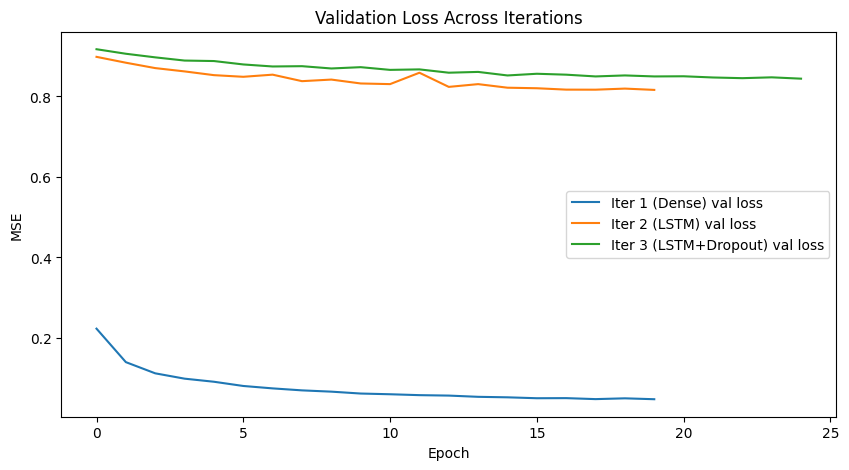

In [44]:
plt.figure(figsize=(10,5))
plt.plot(history_v1.history["val_loss"], label="Iter 1 (Dense) val loss")
plt.plot(history_v2.history["val_loss"], label="Iter 2 (LSTM) val loss")
plt.plot(history_v3.history["val_loss"], label="Iter 3 (LSTM+Dropout) val loss")
plt.legend(); plt.title("Validation Loss Across Iterations"); plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.show()


                           Iteration   ROC-AUC        F1
0                           v1_dense  0.944564  0.057151
1                            v2_lstm  0.913803  0.047512
2  v3_lstm_dropout_optimal_threshold  0.909696  0.156635


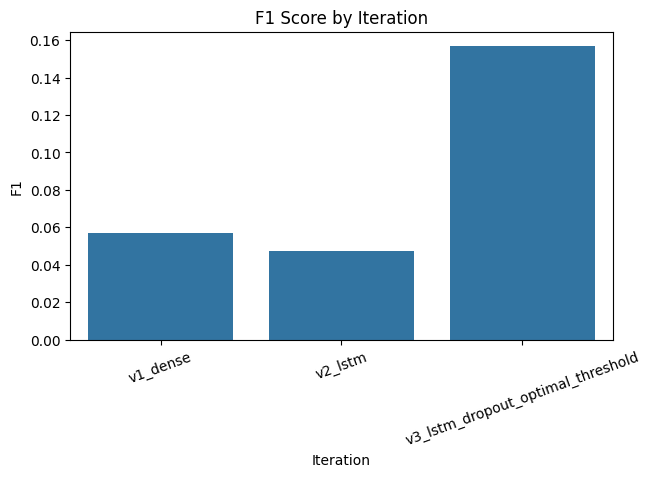

In [45]:
summary = pd.DataFrame({
    "Iteration": list(results.keys()),
    "ROC-AUC": [results[k]["auc"] for k in results],
    "F1": [results[k]["f1"] for k in results],
})
print(summary)

plt.figure(figsize=(7,4))
sns.barplot(x="Iteration", y="F1", data=summary)
plt.xticks(rotation=20)
plt.title("F1 Score by Iteration")
plt.show()


## 11. Spark Shutdown

In [46]:
spark.stop()